In [1]:
import numpy as np
import pandas as pd
import joblib

X_train = np.load('../data/X_train_processed.npy')
X_test = np.load('../data/X_test_processed.npy')

# Targets
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()

import json
with open('../data/feature_names.json') as f:
    feature_names = json.load(f)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train churn rate:", y_train.mean())
print("y_test churn rate:", y_test.mean())

X_train: (5634, 32)
X_test: (1409, 32)
y_train churn rate: 0.2653532126375577
y_test churn rate: 0.2654364797728886


In [2]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)
y_proba_log = log_reg.predict_proba(X_test)[:, 1]  

In [3]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

In [4]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score, confusion_matrix
)

def evaluate_model(name, y_true, y_pred, y_proba):
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 (binary):", f1_score(y_true, y_pred))
    print("F1 (macro):", f1_score(y_true, y_pred, average='macro'))
    print("PR-AUC:", average_precision_score(y_true, y_proba))
    print("ROC-AUC:", roc_auc_score(y_true, y_proba))
    print()

evaluate_model("Logistic Regression", y_test, y_pred_log, y_proba_log)
evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf)

--- Logistic Regression ---
Accuracy: 0.7359829666430092
Precision: 0.5016891891891891
Recall: 0.7941176470588235
F1 (binary): 0.6149068322981367
F1 (macro): 0.7070214507063037
PR-AUC: 0.6333391006790408
ROC-AUC: 0.8419669844222274

--- Random Forest ---
Accuracy: 0.7721788502484032
Precision: 0.5614849187935035
Recall: 0.6470588235294118
F1 (binary): 0.6012422360248447
F1 (macro): 0.7208893743462524
PR-AUC: 0.6060490392422793
ROC-AUC: 0.8247694334650855



In [5]:
def find_optimal_threshold(y_true, y_proba, cost_fn=500, cost_fp=50):
    """
    Scans thresholds from 0.05 to 0.95 and finds the one that MINIMIZES total business cost,
    instead of defaulting to 0.5.
    """
    thresholds = np.arange(0.05, 0.96, 0.01)
    costs = []
    
    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_t).ravel()
        cost = (fn * cost_fn) + (fp * cost_fp)
        costs.append(cost)
    
    best_idx = np.argmin(costs)
    return thresholds[best_idx], costs[best_idx]

best_threshold_log, best_cost_log = find_optimal_threshold(y_test, y_proba_log)
best_threshold_rf, best_cost_rf = find_optimal_threshold(y_test, y_proba_rf)

print(f"Logistic Regression — best threshold: {best_threshold_log:.2f}, cost at that threshold: ₹{best_cost_log:,}")
print(f"Random Forest — best threshold: {best_threshold_rf:.2f}, cost at that threshold: ₹{best_cost_rf:,}")

default_cost_log = find_optimal_threshold(y_test, y_proba_log)[1]  
print(f"\nCost at default 0.5 threshold — Logistic Regression:", 
      (lambda t=0.5: (lambda tn,fp,fn,tp: fn*500+fp*50)(*confusion_matrix(y_test, (y_proba_log>=t).astype(int)).ravel()))())

Logistic Regression — best threshold: 0.22, cost at that threshold: ₹34,600
Random Forest — best threshold: 0.10, cost at that threshold: ₹39,200

Cost at default 0.5 threshold — Logistic Regression: 53250


In [6]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 (macro)', 'PR-AUC', 'ROC-AUC', 'Best threshold', 'Cost at best threshold'],
    'Logistic Regression': [
        accuracy_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_log, average='macro'),
        average_precision_score(y_test, y_proba_log),
        roc_auc_score(y_test, y_proba_log),
        best_threshold_log,
        best_cost_log
    ],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf, average='macro'),
        average_precision_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_rf),
        best_threshold_rf,
        best_cost_rf
    ]
})
print(comparison)

                   Metric  Logistic Regression  Random Forest
0                Accuracy             0.735983       0.772179
1               Precision             0.501689       0.561485
2                  Recall             0.794118       0.647059
3              F1 (macro)             0.707021       0.720889
4                  PR-AUC             0.633339       0.606049
5                 ROC-AUC             0.841967       0.824769
6          Best threshold             0.220000       0.100000
7  Cost at best threshold         34600.000000   39200.000000


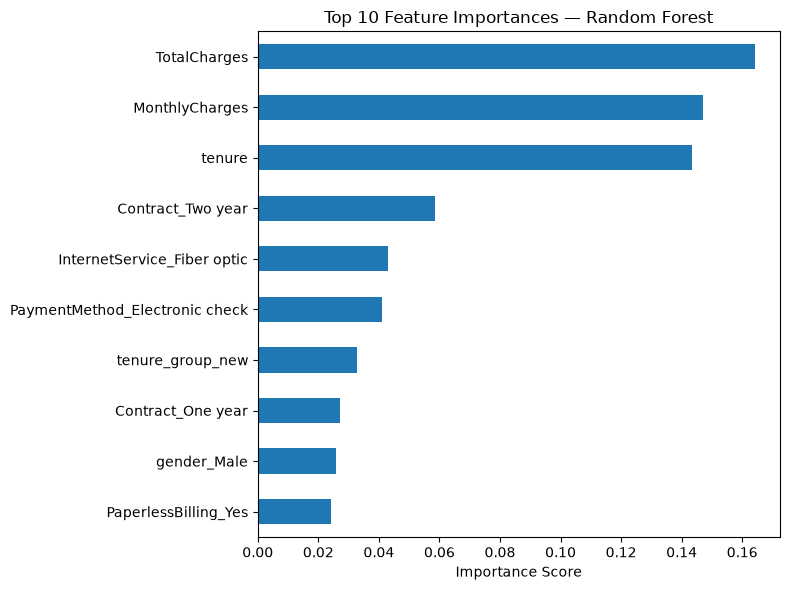

TotalCharges                      0.164265
MonthlyCharges                    0.146982
tenure                            0.143567
Contract_Two year                 0.058370
InternetService_Fiber optic       0.043149
PaymentMethod_Electronic check    0.040909
tenure_group_new                  0.032810
Contract_One year                 0.027143
gender_Male                       0.025773
PaperlessBilling_Yes              0.024209
dtype: float64


In [7]:
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=feature_names)
top10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
top10.sort_values().plot(kind='barh')
plt.title('Top 10 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(top10)

In [8]:
joblib.dump(log_reg, '../models/logistic_regression.pkl')
joblib.dump(rf, '../models/random_forest.pkl')

best_model_info = {
    'model_name': 'random_forest', 
    'optimal_threshold': float(best_threshold_rf)
}
with open('../models/model_config.json', 'w') as f:
    json.dump(best_model_info, f)

In [9]:
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(log_reg, '../models/logistic_regression.pkl')
joblib.dump(rf, '../models/random_forest.pkl')

['../models/random_forest.pkl']

In [10]:
print(os.listdir('../models'))

['logistic_regression.pkl', 'model_config.json', 'random_forest.pkl', 'xgboost_tuned.pkl']


In [11]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

scale_pos_weight: 2.77


In [12]:
from xgboost import XGBClassifier

xgb_baseline = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss' 
)
xgb_baseline.fit(X_train, y_train)

y_pred_xgb_base = xgb_baseline.predict(X_test)
y_proba_xgb_base = xgb_baseline.predict_proba(X_test)[:, 1]

evaluate_model("XGBoost (baseline)", y_test, y_pred_xgb_base, y_proba_xgb_base)

--- XGBoost (baseline) ---
Accuracy: 0.752306600425834
Precision: 0.5263157894736842
Recall: 0.6684491978609626
F1 (binary): 0.5889281507656066
F1 (macro): 0.7058404085468459
PR-AUC: 0.6008225357291502
ROC-AUC: 0.8167377095765842



In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb_grid = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)


grid_search = GridSearchCV(
    estimator=xgb_grid,
    param_grid=param_grid,
    scoring='average_precision',
    cv=5,
    n_jobs=-1,  
    verbose=1   
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated PR-AUC:", grid_search.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best cross-validated PR-AUC: 0.6658995479175231


In [14]:
best_xgb = grid_search.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

evaluate_model("XGBoost (tuned)", y_test, y_pred_xgb, y_proba_xgb)

--- XGBoost (tuned) ---
Accuracy: 0.7402413058907026
Precision: 0.5068493150684932
Recall: 0.7914438502673797
F1 (binary): 0.6179540709812108
F1 (macro): 0.7105899387164119
PR-AUC: 0.6642488970282465
ROC-AUC: 0.8456818827662816



In [15]:
best_threshold_xgb, best_cost_xgb = find_optimal_threshold(y_test, y_proba_xgb)
print(f"XGBoost — best threshold: {best_threshold_xgb:.2f}, cost at that threshold: ₹{best_cost_xgb:,}")

XGBoost — best threshold: 0.20, cost at that threshold: ₹35,800


In [16]:
comparison_3way = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 (macro)', 'PR-AUC', 'ROC-AUC', 'Best threshold', 'Cost at best threshold'],
    'Logistic Regression': [
        accuracy_score(y_test, y_pred_log), precision_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_log), f1_score(y_test, y_pred_log, average='macro'),
        average_precision_score(y_test, y_proba_log), roc_auc_score(y_test, y_proba_log),
        best_threshold_log, best_cost_log
    ],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf), precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf), f1_score(y_test, y_pred_rf, average='macro'),
        average_precision_score(y_test, y_proba_rf), roc_auc_score(y_test, y_proba_rf),
        best_threshold_rf, best_cost_rf
    ],
    'XGBoost': [
        accuracy_score(y_test, y_pred_xgb), precision_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb), f1_score(y_test, y_pred_xgb, average='macro'),
        average_precision_score(y_test, y_proba_xgb), roc_auc_score(y_test, y_proba_xgb),
        best_threshold_xgb, best_cost_xgb
    ]
})
print(comparison_3way)

                   Metric  Logistic Regression  Random Forest       XGBoost
0                Accuracy             0.735983       0.772179      0.740241
1               Precision             0.501689       0.561485      0.506849
2                  Recall             0.794118       0.647059      0.791444
3              F1 (macro)             0.707021       0.720889      0.710590
4                  PR-AUC             0.633339       0.606049      0.664249
5                 ROC-AUC             0.841967       0.824769      0.845682
6          Best threshold             0.220000       0.100000      0.200000
7  Cost at best threshold         34600.000000   39200.000000  35800.000000


In [17]:
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(best_xgb, '../models/xgboost_tuned.pkl')

costs = {'logistic_regression': best_cost_log, 'random_forest': best_cost_rf, 'xgboost': best_cost_xgb}
winner = min(costs, key=costs.get)
thresholds = {'logistic_regression': best_threshold_log, 'random_forest': best_threshold_rf, 'xgboost': best_threshold_xgb}

best_model_info = {
    'model_name': winner,
    'optimal_threshold': float(thresholds[winner])
}
with open('../models/model_config.json', 'w') as f:
    json.dump(best_model_info, f)

print(f"Winning model: {winner} (threshold: {thresholds[winner]:.2f})")

Winning model: logistic_regression (threshold: 0.22)


In [18]:
print("Logistic Regression flags:", ((y_proba_log >= best_threshold_log).sum()), "out of", len(y_test))
print("Random Forest flags:", ((y_proba_rf >= best_threshold_rf).sum()), "out of", len(y_test))
print("XGBoost flags:", ((y_proba_xgb >= best_threshold_xgb).sum()), "out of", len(y_test))

Logistic Regression flags: 901 out of 1409
Random Forest flags: 1015 out of 1409
XGBoost flags: 892 out of 1409


In [19]:
import shap

In [20]:
explainer = shap.LinearExplainer(log_reg, X_train)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)  # should match X_test.shape

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


SHAP values shape: (1409, 32)


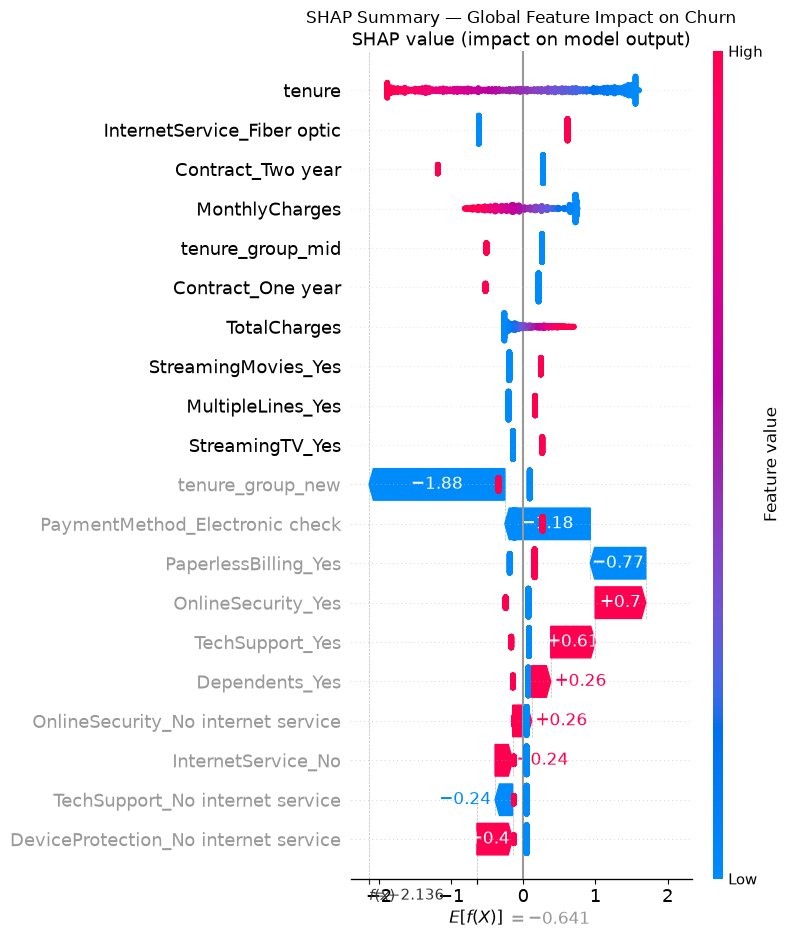

In [24]:
import os
os.makedirs('../reports', exist_ok=True)

plt.savefig('../reports/shap_summary.png', dpi=150)
plt.show()

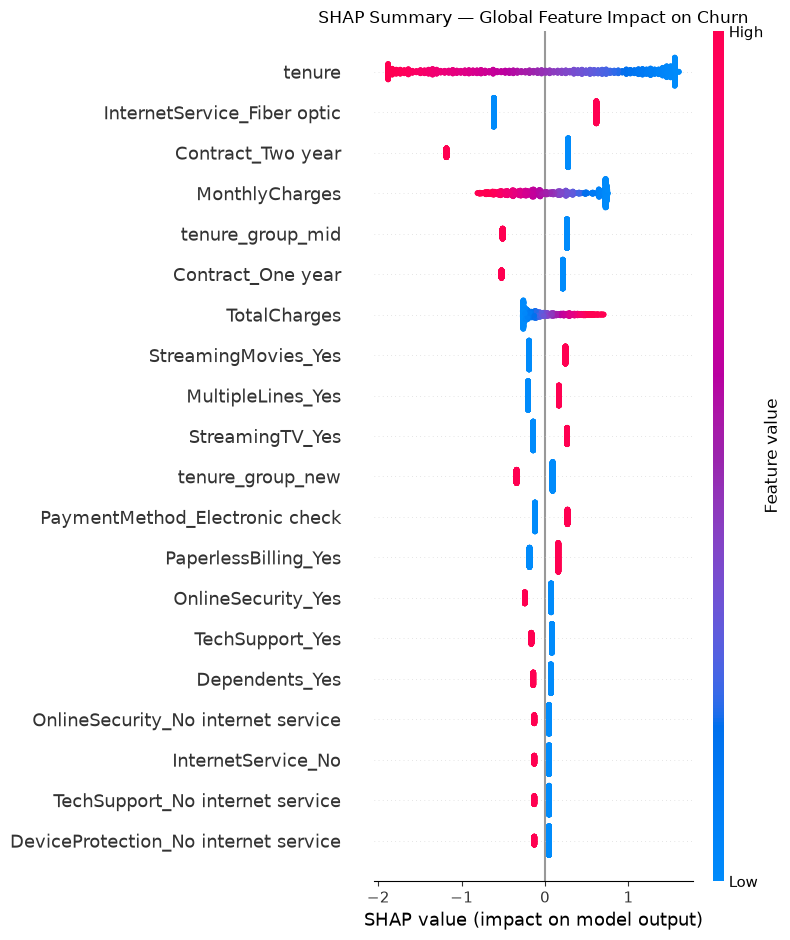

In [25]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title("SHAP Summary — Global Feature Impact on Churn")
plt.tight_layout()
plt.savefig('../reports/shap_summary.png', dpi=150)  
plt.show()

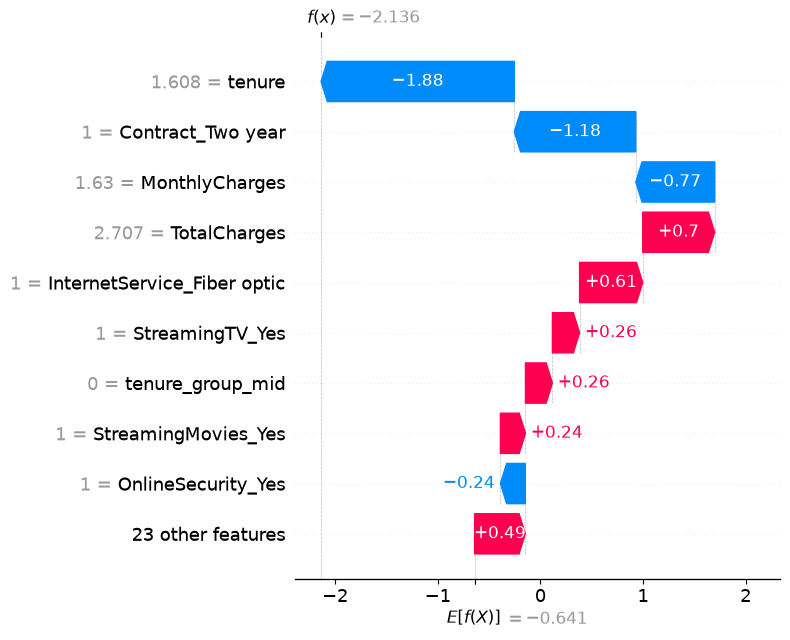

In [26]:
customer_index = 0  

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[customer_index],
        base_values=explainer.expected_value,
        data=X_test[customer_index],
        feature_names=feature_names
    ),
    show=False
)
plt.tight_layout()
plt.savefig('../reports/shap_waterfall_example.png', dpi=150)
plt.show()

In [27]:
def get_top_reasons(shap_values_row, feature_names, top_n=3):
    """
    Returns the top N features (by absolute SHAP value) pushing this customer toward churn.
    Only returns features pushing TOWARD churn (positive SHAP value), not away from it.
    """
    shap_series = pd.Series(shap_values_row, index=feature_names)
    churn_pushing = shap_series[shap_series > 0].sort_values(ascending=False)
    return churn_pushing.head(top_n)

top_reasons = get_top_reasons(shap_values[customer_index], feature_names)
print("Top 3 reasons this customer might churn:")
print(top_reasons)

Top 3 reasons this customer might churn:
TotalCharges                   0.700803
InternetService_Fiber optic    0.614889
StreamingTV_Yes                0.264733
dtype: float64


In [28]:
joblib.dump(explainer, '../models/shap_explainer.pkl')

['../models/shap_explainer.pkl']